## 1. Préparation des données

Dans cette section, nous importons et inspectons le jeu de données utilisé pour la prévision du chiffre d'affaires. Le jeu de données contient des données mensuelles de chiffre d'affaires spécifiques au client.

- Variable cible : `CA_HT_Recalc` — chiffre d'affaires mensuel (hors taxes)  
- Colonnes temporelles : `Annee`, `Mois` — combinées pour former une chronologie continue  
- Type de jeu de données : série chronologique agrégée mensuellement


In [ ]:
#step 1: run first cell with
!pip uninstall -y numpy
!pip install numpy==1.23.5

Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Successfully uninstalled numpy-1.23.5
  Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.40.2 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is incompatible.
flax 0.10.6 requires jax>=0.5.1, but you have jax 0.4.30 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
scikit-image 0.25.2 requires numpy>=1.24, but you have 

In [ ]:
#step 2: run second cell with
!pip install --upgrade --force-reinstall pmdarima

  Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached cython-3.1.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.5 kB)
  Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached pandas-2.2.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (89 kB)
  Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached scipy-1.15.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached statsmodels-0.14.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.2 kB)
  Using cached urllib3-2.4.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached packaging-25.0-py3-none-

In [ ]:
!pip install --upgrade --force-reinstall tensorflow==2.12.0

  Using cached tensorflow-2.12.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.4 kB)
  Using cached absl_py-2.3.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.4.0-py3-none-any.whl.metadata (1.1 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached grpcio-1.71.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.8 kB)
  Using cached h5py-3.13.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.5 kB)
  Using cached jax-0.6.1-py3-none-any.whl.metadata (13 kB)
  Using cached keras-2.12.0-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
  Using cached op

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CAF_Data set Aya.xlsx to CAF_Data set Aya (1).xlsx


In [ ]:
import pandas as pd

# Charger les données
data = pd.read_excel('CAF_Data set Aya.xlsx', sheet_name=None)
df = data['Feuil1']

# Renommer les colonnes
df.columns = ['Client', 'Domaine', 'SousDomaine', 'CA_Recurrent', 'Annee', 'Mois', 'CA_HT_Recalc']

# Créer une colonne datetime correcte
df['Date'] = pd.to_datetime(dict(year=df['Annee'], month=df['Mois'], day=1))

# Grouper par date et sommer
revenu_mensuel_df = df.groupby('Date')['CA_HT_Recalc'].sum().reset_index()

In [ ]:
df.head(5)

,Client,Domaine,SousDomaine,CA_Recurrent,Annee,Mois,CA_HT_Recalc,Date
0,CLIENT 1,Domaine 1,Sous-domaine 11,R,2022,1,373431.25000,2022-01-01
1,CLIENT 1,Domaine 1,Sous-domaine 11,R,2022,2,-43087.78001,2022-02-01
2,CLIENT 1,Domaine 1,Sous-domaine 11,R,2022,3,360743.20000,2022-03-01
3,CLIENT 1,Domaine 1,Sous-domaine 11,R,2022,4,35600.10000,2022-04-01
4,CLIENT 1,Domaine 1,Sous-domaine 11,R,2022,5,357016.87000,2022-05-01


In [ ]:
df.describe()

,Annee,Mois,CA_HT_Recalc,Date
count,114743.000000,114743.000000,114743.000000,114743
mean,2022.965331,6.398159,878.331834,2023-06-01 00:00:00.752986880
min,2022.000000,1.000000,-191973.749980,2022-01-01 00:00:00
25%,2022.000000,3.000000,39.800000,2022-09-01 00:00:00
50%,2023.000000,6.000000,160.650000,2023-06-01 00:00:00
75%,2024.000000,9.000000,608.060000,2024-03-01 00:00:00
max,2024.000000,12.000000,399004.500000,2024-12-01 00:00:00
std,0.816237,3.450777,4647.993083,NaN


- Le jeu de données contient 114 743 enregistrements allant de janvier 2022 à décembre 2024.
- Le chiffre d'affaires mensuel hors taxes (CA_HT_Recalc) présente une forte variabilité, avec une moyenne d'environ 878 €, mais une valeur minimale négative (-191 973 €) (erreur ou remboursement).
- Le champ Date a bien été converti, ce qui permettra l’analyse de series temporelles

In [ ]:
# 📌 Étape 1.x : Résumé initial du jeu de données

# ⚙️ Import des bibliothèques utiles
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from scipy.stats import skew, kurtosis

# 📋 Informations générales
print("📋 Informations sur le jeu de données :")
print(df.info())

# 🧹 Vérification des valeurs manquantes
print("\n🧹 Valeurs manquantes par colonne :")
print(df.isnull().sum())

# 📈 Statistiques descriptives
print("\n📈 Statistiques descriptives des variables numériques :")
print(df.describe())

# 👀 Aperçu des premières lignes
print("\n🔍 Aperçu des 5 premières lignes :")
print(df.head())


📋 Informations sur le jeu de données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114743 entries, 0 to 114742
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Client        114743 non-null  object        
 1   Domaine       114743 non-null  object        
 2   SousDomaine   114743 non-null  object        
 3   CA_Recurrent  114743 non-null  object        
 4   Annee         114743 non-null  int64         
 5   Mois          114743 non-null  int64         
 6   CA_HT_Recalc  114743 non-null  float64       
 7   Date          114743 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 7.0+ MB
None

🧹 Valeurs manquantes par colonne :
Client          0
Domaine         0
SousDomaine     0
CA_Recurrent    0
Annee           0
Mois            0
CA_HT_Recalc    0
Date            0
dtype: int64

📈 Statistiques descriptives des variables numériques :
      

- No missing values detected
- All date information was successfully parsed into a single `Date` column
- The dataset is ready for time series modeling without major cleaning


## 2. Exploration des données

Avant de sélectionner un modèle de prévision, nous devons d'abord comprendre le comportement des données de manière visuelle et statistique.

Dans cette étape, nous allons :
- Tracer le chiffre d'affaires mensuel  
- Identifier les tendances ou motifs saisonniers récurrents  
- Vérifier les propriétés statistiques de la variable cible


 Agréger et tracer le chiffre d'affaires mensuel


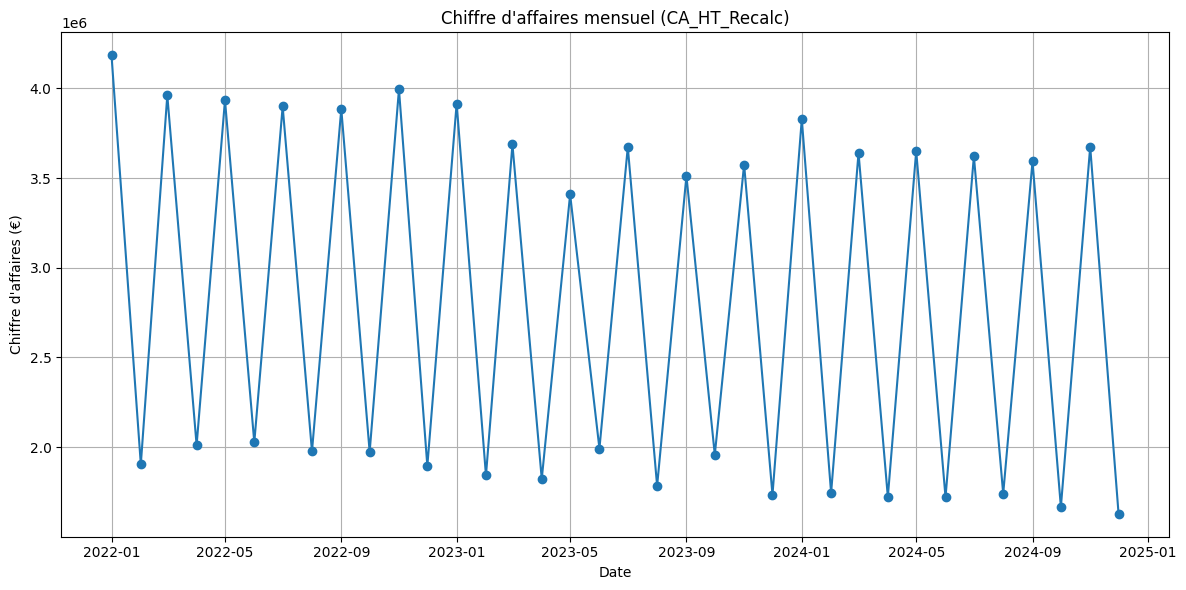

In [ ]:
import matplotlib.pyplot as plt

# Regrouper par date (au cas où il y aurait plusieurs clients ou domaines par mois)
revenu_mensuel = df.groupby('Date')['CA_HT_Recalc'].sum()

# Tracer la série temporelle
plt.figure(figsize=(12, 6))
plt.plot(revenu_mensuel.index, revenu_mensuel.values, marker='o', linestyle='-')
plt.title("Chiffre d'affaires mensuel (CA_HT_Recalc)")
plt.xlabel("Date")
plt.ylabel("Chiffre d'affaires (€)")
plt.grid(True)
plt.tight_layout()
plt.show()

### 📈 Analyse exploratoire de la série temporelle

Le graphique représentant l'évolution du chiffre d'affaires mensuel (`CA_HT_Recalc`) met en évidence plusieurs éléments importants :

- 📊 **Saisonnalité apparente** : On observe des variations cycliques régulières, avec des pics et des creux à intervalles constants. Cela suggère une structure saisonnière dans les données.
- 📉 **Tendance globale stable** : Sur l’ensemble de la période 2022–2024, il n’y a pas de tendance fortement croissante ou décroissante. Le chiffre d’affaires oscille autour de niveaux similaires d’une année à l’autre.
- 🔁 **Variabilité récurrente** : La série semble influencée par des facteurs périodiques (internes ou externes à l’entreprise), ce qui la rend adaptée à une modélisation temporelle.

➡️ Ces caractéristiques suggèrent que les données sont bien adaptées à l’utilisation de modèles de séries temporelles tels que :
- **SARIMA** (ARIMA avec composante saisonnière),
- **Prophet** (développé par Facebook pour les séries saisonnières),
- **RNN/LSTM** pour capturer les dépendances temporelles complexes.




 Diagramme en boîte saisonnier (par mois)


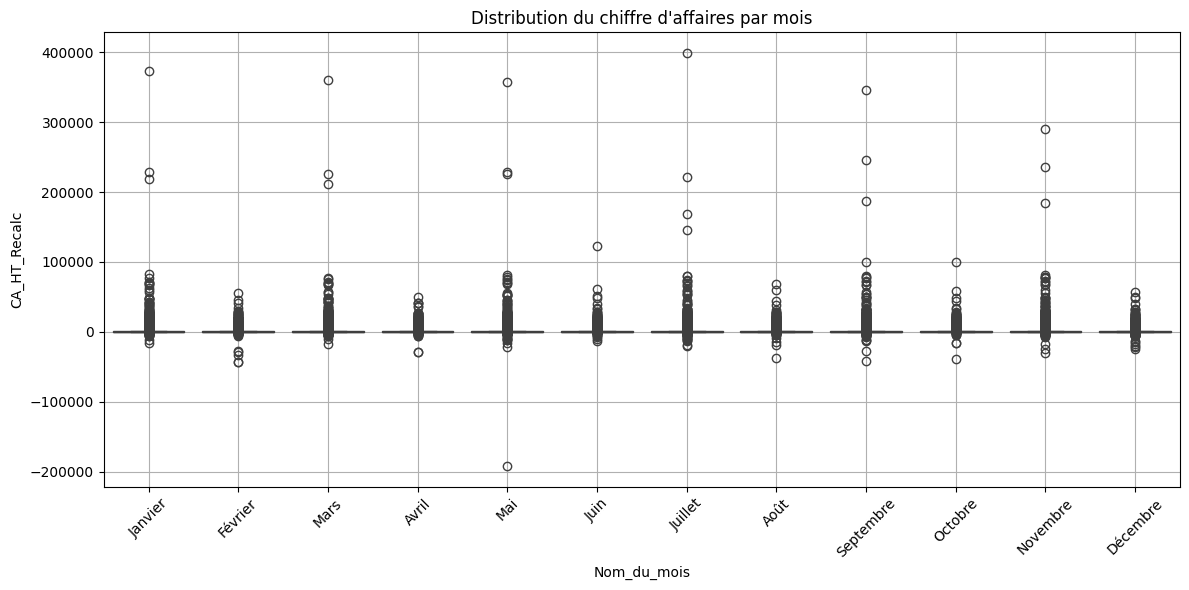

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extraire le numéro du mois
df['Mois'] = df['Date'].dt.month

# Mapper les noms français des mois
mois_fr = {
    1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril',
    5: 'Mai', 6: 'Juin', 7: 'Juillet', 8: 'Août',
    9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'
}
df['Nom_du_mois'] = df['Mois'].map(mois_fr)

# Ordre des mois pour l'affichage
ordre_mois = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
              'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

# Créer le boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Nom_du_mois', y='CA_HT_Recalc', data=df, order=ordre_mois)
plt.title('Distribution du chiffre d\'affaires par mois')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


📊 **Analyse de la saisonnalité** :
- Ce diagramme en boîte révèle un **motif récurrent** certains mois — certains mois présentent systématiquement un chiffre d'affaires plus élevé ou plus faible.  
- Cela confirme que les données sont **saisonnières**, ce qui justifie l'utilisation de modèles comme **SARIMA** ou **LSTM** qui gèrent explicitement la saisonnalité.


## Décomposition de la série

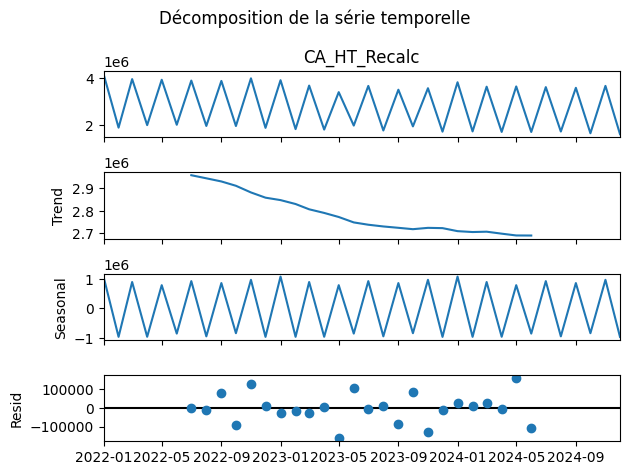

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(revenu_mensuel, model='additive', period=12)
decomposition.plot()
plt.suptitle("Décomposition de la série temporelle")
plt.tight_layout()
plt.show()


### 🔍 Analyse de la décomposition de la série temporelle

- La série `CA_HT_Recalc` présente une **saisonnalité mensuelle marquée et régulière**, ce qui reflète des cycles d’activité récurrents (ex. : facturation).
- La **tendance est légèrement décroissante** sur la période 2022–2024, indiquant une baisse progressive du chiffre d'affaires.
- Les **résidus sont faibles, centrés autour de zéro et sans structure apparente**, ce qui confirme la pertinence de la décomposition additive.
- Ces éléments suggèrent que la série est **bien adaptée à une modélisation avec SARIMA ou Prophet**, en tenant compte de la tendance et de la saisonnalité annuelle.


Test ADF pour la stationnarité


In [ ]:
# Test de stationnarité ADF (Augmented Dickey-Fuller)
adf_result = adfuller(revenu_mensuel)

# Affichage des résultats du test ADF
print("Statistique ADF :", round(adf_result[0], 4))
print("p-value :", round(adf_result[1], 4))

# Interprétation du résultat
if adf_result[1] <= 0.05:
    print("✅ Les données sont stationnaires (adaptées aux modèles ARIMA/SARIMA).")
else:
    print("⚠️ Les données ne sont pas stationnaires (une différenciation peut être nécessaire).")


Statistique ADF : -1.1597
p-value : 0.6907
⚠️ Les données ne sont pas stationnaires (une différenciation peut être nécessaire).


### 🔍 Interprétation du test ADF selon la méthode théorique

Le **test de Dickey-Fuller augmenté (ADF)** a été utilisé pour évaluer la **stationnarité** de la série chronologique du chiffre d'affaires mensuel.  
Ce test repose sur l’hypothèse suivante :

- **\( H_0 \)** : la série possède une **racine unitaire**, donc elle est **non stationnaire** ;
- **\( H_1 \)** : la série est **stationnaire**.

📌 Dans notre cas :

- Statistique ADF = **−1.1597**  
- Valeur critique à 5 % = **−2.9572**

➡️ Comme **−1.1597 > −2.9572**, nous **ne rejetons pas \( H_0 \)**.  
➡️ Donc, la série est **non stationnaire**.


### ✅ Conclusion :

> **La série n’est pas stationnaire**, ce qui est typique d’une série avec une tendance.  
> Une **différenciation** sera donc probablement nécessaire pour appliquer des modèles de prévision comme **ARIMA** ou **SARIMA**.


### 📊 Analyse de la distribution

L'histogramme du chiffre d'affaires mensuel permet de visualiser la forme globale de la distribution.  
Combiné avec la courbe de densité (KDE), il met en évidence :
- une éventuelle **asymétrie**,
- des **saisonnalités** masquées,
- ou des **valeurs extrêmes**.

Cela aide à décider s’il est nécessaire d’appliquer une **transformation (log, diff)** avant la modélisation.


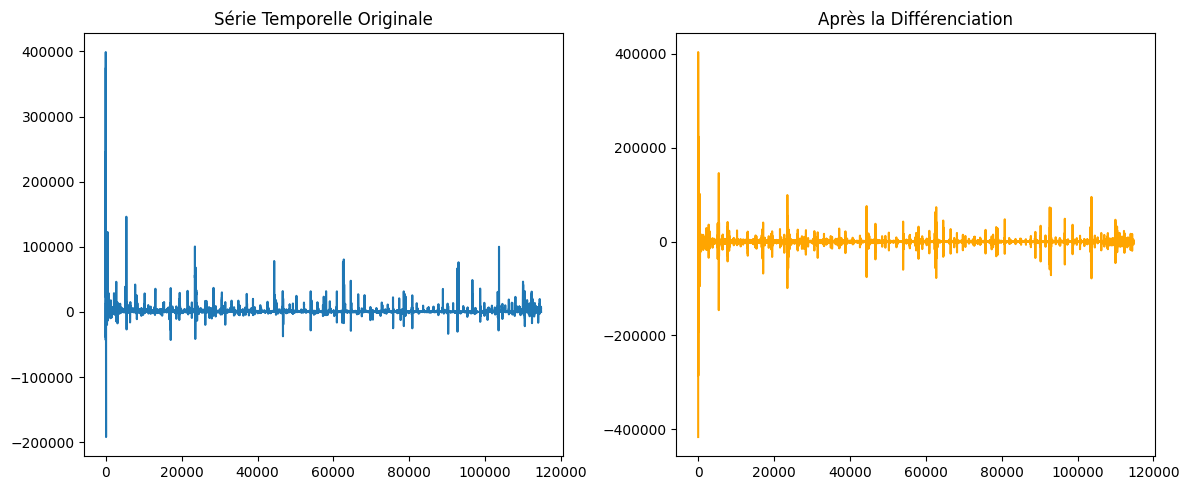

p-valeur ADF après différenciation : 0.0


In [ ]:
# Différenciation d'ordre 1 et test ADF

# Appliquer la différenciation d'ordre 1
df_diff = df['CA_HT_Recalc'].diff().dropna()

# Tracer la série originale et la série différenciée
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(df['CA_HT_Recalc'], label='Original')
plt.title('Série Temporelle Originale')
plt.subplot(1,2,2)
plt.plot(df_diff, label='Différenciée', color='orange')
plt.title('Après la Différenciation')
plt.tight_layout()
plt.show()

# Effectuer le test ADF sur la série différenciée
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df_diff)
print(f"p-valeur ADF après différenciation : {adf_result[1]}")


Après avoir appliqué la différenciation d'ordre 1, le test ADF affiche une p-valeur de 0,000, ce qui confirme que la série est désormais stationnaire. Cette transformation aide le modèle ARIMA à mieux fonctionner et à produire des prévisions plus fiables.


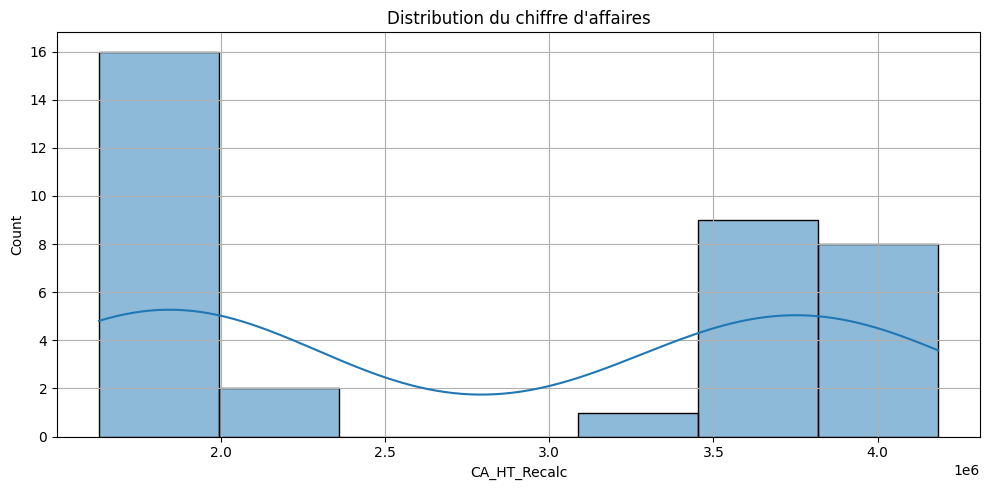

In [ ]:
# 3. Analyse de la distribution
plt.figure(figsize=(10, 5))  # Définir la taille du graphique

# Tracer l'histogramme du chiffre d'affaires mensuel avec la courbe de densité (KDE)
sns.histplot(revenu_mensuel_df['CA_HT_Recalc'], kde=True)

plt.title('Distribution du chiffre d\'affaires')  # Titre du graphique
plt.grid(True)  # Afficher la grille
plt.tight_layout()  # Ajuster les marges automatiquement
plt.show()  # Afficher le graphique


📊 Analyse de la distribution du chiffre d'affaires mensuel
La distribution est bimodale : on observe deux pics distincts autour de 1,9M€ et 3,7M€.

- Cette forme suggère deux comportements différents dans les données : possiblement deux types de clients, de périodes, ou d’activités.

- La distribution est asymétrique et non normale, ce qui est confirmé visuellement par l’absence de symétrie autour d’une moyenne unique.

- Cette hétérogénéité pourrait indiquer :

- Un changement structurel dans l’activité (fusion, croissance, saisonnalité marquée...),

- Ou la présence de sous-groupes distincts (petits vs gros clients, canaux différents, etc.).

### Analyse de la distribution du chiffre d'affaires

Pour mieux comprendre la structure de notre variable cible `CA_HT_Recalc` (chiffre d'affaires mensuel), nous explorons sa distribution statistique.

Nous examinons :
- Le caractère symétrique ou asymétrique du chiffre d'affaires  
- Si le chiffre d'affaires suit une distribution normale  
- La présence de valeurs extrêmes ou une distribution aplatie  

L'histogramme et l'estimation de densité par noyau (KDE) ci-dessous nous donnent une impression visuelle.


In [ ]:
from scipy.stats import skew, kurtosis

print("\n📈 Asymétrie et Aplatissement :")
print(f"Asymétrie (Skewness) : {skew(revenu_mensuel_df['CA_HT_Recalc']):.4f}")
print(f"Aplatissement (Kurtosis) : {kurtosis(revenu_mensuel_df['CA_HT_Recalc']):.4f}")



📈 Asymétrie et Aplatissement :
Asymétrie (Skewness) : 0.0360
Aplatissement (Kurtosis) : -1.8838


📈 **Asymétrie (Skewness)** = 0,0360  
📉 **Kurtosis** = -1,8838

#### 📊 Interprétation :

- **Asymétrie ~ 0** : La distribution du chiffre d'affaires est **approximativement symétrique**.  
  Il n’y a pas de queue significative à gauche ou à droite — les données sont équilibrées autour de la moyenne.

- **Kurtosis < 0** : La distribution est **platicurtique**, ce qui signifie :
  - Elle a des **queues plus plates** qu'une distribution normale.  
  - Il y a moins de valeurs extrêmes ou d'observations aberrantes.  
  - Les valeurs de chiffre d'affaires ont tendance à être plus régulièrement regroupées.

#### ✅ Conclusion :
- Les valeurs de chiffre d'affaires sont globalement bien réparties.  
- Cela permet d’appliquer des modèles sans avoir besoin de transformations lourdes ou de gestion des valeurs extrêmes.


## 3. Séparation Entraînement/Test

1.   Élément de liste
2.   Élément de liste



Pour évaluer la performance des prévisions de manière réaliste, nous divisons le jeu de données en :
- **Ensemble d'entraînement** : Toutes les données avant janvier 2024  
- **Ensemble de test** : À partir de janvier 2024 (12 mois)

Cela simule la prédiction de **données futures non vues** en se basant uniquement sur les tendances passées — comme le ferait un véritable modèle de prévision en production.


In [ ]:
# ✅ Étape 3.1 : Préparation des données pour le LSTM

# Définir 'Date' comme index
revenu_mensuel_df = revenu_mensuel_df.set_index('Date')

# Vérifier que la colonne cible est bien présente
print("Colonnes disponibles :", revenu_mensuel_df.columns)  # Doit afficher 'CA_HT_Recalc'

# Diviser les données en ensemble d'entraînement et de test
train = revenu_mensuel_df.loc[:'2023-12-01']
test = revenu_mensuel_df.loc['2024-01-01':]

# ✅ Étape 3.2 : Afficher la taille des ensembles
print(f"Taille de l'ensemble d'entraînement : {len(train)} mois")
print(f"Taille de l'ensemble de test : {len(test)} mois")


Colonnes disponibles : Index(['CA_HT_Recalc'], dtype='object')
Taille de l'ensemble d'entraînement : 24 mois
Taille de l'ensemble de test : 12 mois


📌 **Important** :  
Il s'agit d'une **séparation chronologique**, et non aléatoire. Les modèles de séries temporelles dépendent de la séquence — l'entraînement doit donc inclure uniquement les **données passées** par rapport à la période de test.


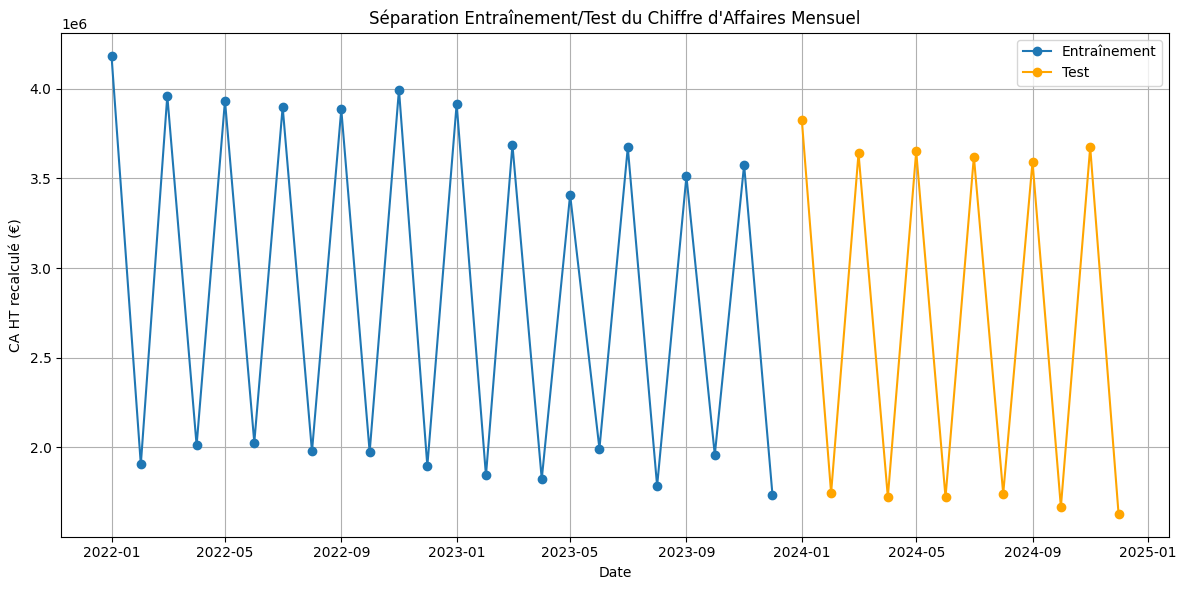

In [ ]:
import matplotlib.pyplot as plt

# ✅ Visualisation de la séparation entraînement/test
plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label='Entraînement', marker='o')
plt.plot(test.index, test.values, label='Test', marker='o', color='orange')
plt.title("Séparation Entraînement/Test du Chiffre d'Affaires Mensuel")
plt.xlabel('Date')
plt.ylabel('CA HT recalculé (€)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


📉 **Observation** :
- L'ensemble de test (2024) poursuit le motif saisonnier observé dans les données d'entraînement.  
- La baisse du chiffre d'affaires durant certains mois est cohérente — cela soutient l'utilisation de modèles comme **SARIMA** et **Hybrid ARIMA+LSTM** capables de capturer efficacement la **saisonnalité**.

✅ La séparation semble équilibrée et prête pour l'entraînement du modèle.


<Figure size 1200x500 with 0 Axes>

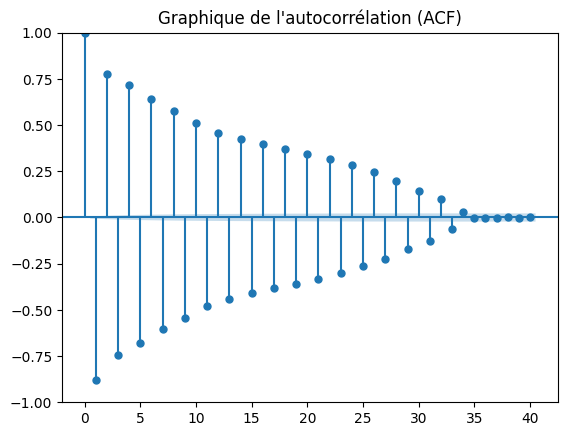

<Figure size 1200x500 with 0 Axes>

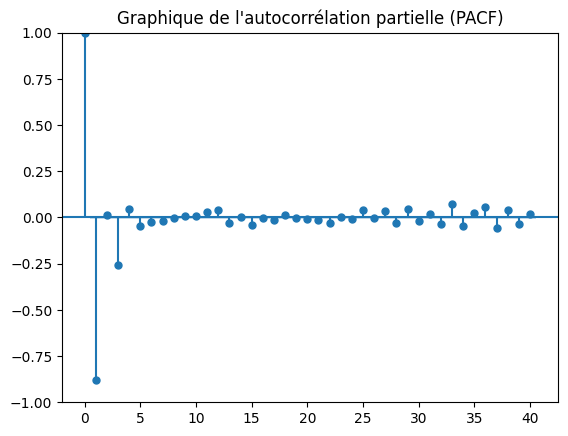

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Tracer l'autocorrélation (ACF)
plt.figure(figsize=(12,5))
plot_acf(df_diff, lags=40)
plt.title("Graphique de l'autocorrélation (ACF)")

# Tracer l'autocorrélation partielle (PACF)
plt.figure(figsize=(12,5))
plot_pacf(df_diff, lags=40)
plt.title("Graphique de l'autocorrélation partielle (PACF)")
plt.show()


### Analyse de l'autocorrélation (ACF & PACF)

Pour guider la sélection du modèle ARIMA, nous avons tracé l'ACF et la PACF de la série temporelle différenciée :

- **L'ACF** montre une décroissance progressive, ce qui indique que des termes de moyenne mobile (MA) pourraient être nécessaires.
- **La PACF** présente une coupure nette après le décalage 1, ce qui suggère un terme autorégressif (AR) d'ordre 1.

Sur cette base, nous pouvons envisager provisoirement un modèle **ARIMA(1,1,0)** ou **ARIMA(1,1,1)**, puis affiner le choix en utilisant des métriques de performance du modèle telles que l’AIC et la RMSE.

Ces graphiques sont des outils de diagnostic précieux pour confirmer que la série est désormais stationnaire et pour faire des choix éclairés concernant les paramètres d’ARIMA.


## 4.1.1 ARIMA (Auto-Régressif Intégré à Moyenne Mobile)

**ARIMA** est un modèle statistique classique utilisé pour prévoir les données de séries temporelles.  
Il suppose l'absence de saisonnalité et repose sur :
- **AR (Auto-Régressif)** : Influence des valeurs passées  
- **I (Intégré)** : Différenciation pour rendre les données stationnaires  
- **MA (Moyenne Mobile)** : Erreurs de prévision passées

Nous utilisons `auto_arima()` de la bibliothèque `pmdarima` pour déterminer automatiquement les meilleurs paramètres (p,d,q).


In [ ]:
from pmdarima import auto_arima
import matplotlib.pyplot as plt
import pandas as pd

# ✅ S'assurer que l'index est bien de type datetime
train.index = pd.to_datetime(train.index)
test.index = pd.to_datetime(test.index)

# ✅ Étape 4.1.1 : Entraînement du modèle ARIMA (sans saisonnalité)
modele_arima = auto_arima(
    train['CA_HT_Recalc'],
    seasonal=False,
    trace=True,
    suppress_warnings=True
)

# ✅ Étape 4.1.2 : Prédiction sur la période de test
nb_periodes = len(test)
previsions_arima = modele_arima.predict(n_periods=nb_periodes)

# ✅ Étape 4.1.3 : Convertir en série temporelle avec index correct
previsions_arima = pd.Series(previsions_arima, index=test.index)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=657.825, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=786.202, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=764.224, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=781.544, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=749.353, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=657.471, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=751.673, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,1)(0,0,0)[0]             : AIC=659.125, Time=0.08 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=653.614, Time=0.11 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=674.399, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=663.511, Time=0.05 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=654.642, Time=0.19 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0] intercept
Total fit time: 1.549 seconds


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


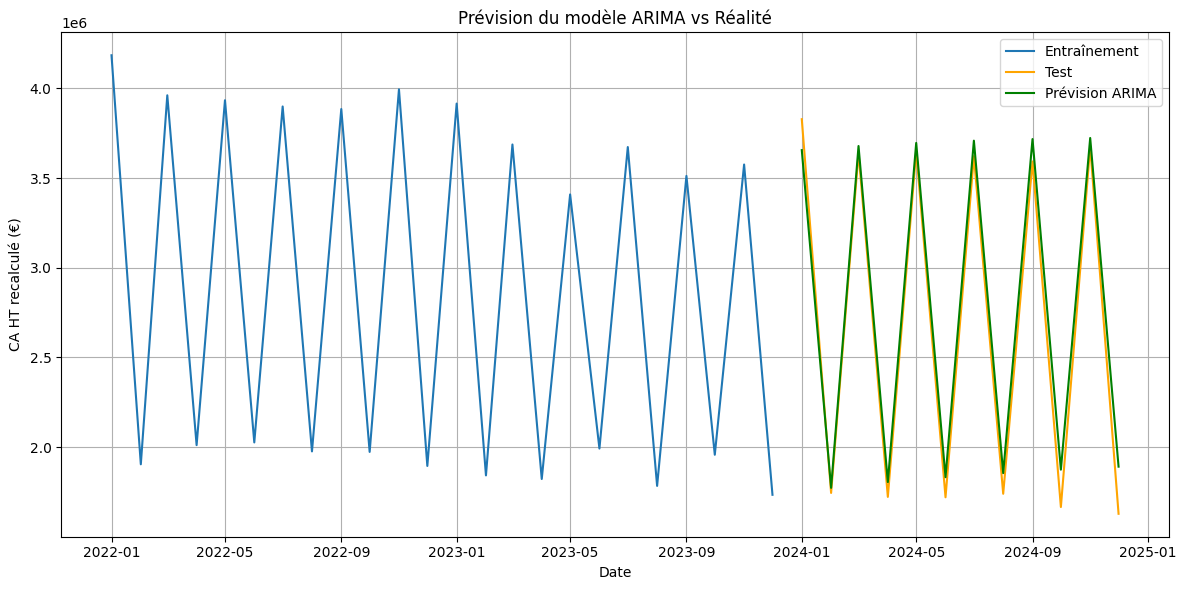

In [ ]:
# ✅ Visualisation des prévisions ARIMA comparées aux données réelles
plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label='Entraînement')
plt.plot(test.index, test.values, label='Test', color='orange')
plt.plot(test.index, previsions_arima, label='Prévision ARIMA', color='green')
plt.title("Prévision du modèle ARIMA vs Réalité")
plt.xlabel("Date")
plt.ylabel("CA HT recalculé (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


📉 **Résultats ARIMA** :
- Le modèle ARIMA fonctionne bien sur la tendance générale, mais a un peu de mal à capturer les hausses et baisses répétées.  
- Cela est attendu, car ARIMA ne **prend pas en compte la saisonnalité** — ce qui le rend moins adapté aux données commerciales cycliques.  
- Il fournit néanmoins une prévision de base utile et permet d’identifier la structure **tendance + bruit** des données.

➡️ Ensuite, nous testerons **SARIMA**, qui gère explicitement la saisonnalité.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['CA_HT_Recalc'], previsions_arima)
rmse = np.sqrt(mean_squared_error(test['CA_HT_Recalc'], previsions_arima))

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")


MAE : 110399.38
RMSE : 130515.23


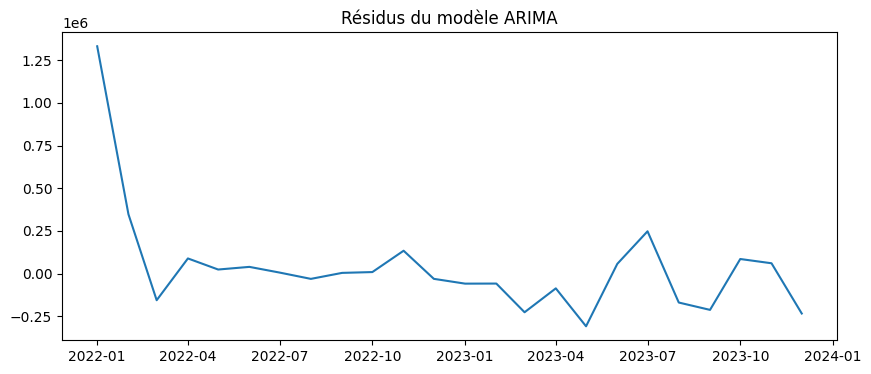

Test de Ljung-Box (ARIMA) :
     lb_stat  lb_pvalue
10  1.953328   0.996685


In [ ]:
# Analyse des résidus ARIMA
residus_arima = modele_arima.resid()

# Visualisation
plt.figure(figsize=(10,4))
plt.plot(residus_arima)
plt.title("Résidus du modèle ARIMA")
plt.show()

# Test de bruit blanc (Ljung-Box)
from statsmodels.stats.diagnostic import acorr_ljungbox
print("Test de Ljung-Box (ARIMA) :")
print(acorr_ljungbox(residus_arima, lags=[10], return_df=True))


## 4.1.2 SARIMA (ARIMA Saisonnier)

SARIMA est une extension d’ARIMA qui modélise la **saisonnalité** — un motif répétitif apparaissant à intervalles réguliers (par exemple : mensuel, trimestriel).

Il utilise 7 paramètres :
- **(p,d,q)** – identiques à ARIMA : autorégression, différenciation, moyenne mobile  
- **(P,D,Q,m)** – composantes saisonnières, où `m` est la fréquence saisonnière (ex. : `12` pour des données mensuelles)

Ici, nous effectuons une **recherche par grille manuelle** pour trouver la meilleure configuration SARIMA en nous basant sur le **critère AIC (Akaike Information Criterion)**.


In [ ]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import numpy as np

# ✅ Ignorer les avertissements pour plus de lisibilité
warnings.filterwarnings("ignore")

# ✅ Définir les plages de paramètres pour SARIMA
p = d = q = range(0, 3)        # Paramètres ARIMA
P = D = Q = range(0, 2)        # Paramètres saisonniers
m = 12                         # Saison annuelle (12 mois)

# Générer toutes les combinaisons possibles de paramètres
pdq = list(itertools.product(p, d, q))
parametres_saisonniers = list(itertools.product(P, D, Q, [m]))

# Initialisation des meilleures valeurs
meilleur_aic = np.inf
meilleurs_parametres = None

# ✅ Recherche du meilleur modèle SARIMA (Grid Search)
for param in pdq:
    for saisonnier in parametres_saisonniers:
        try:
            modele = SARIMAX(
                train,                   # Série temporelle d'entraînement
                order=param,
                seasonal_order=saisonnier,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            resultats = modele.fit(disp=False)
            if resultats.aic < meilleur_aic:
                meilleur_aic = resultats.aic
                meilleurs_parametres = (param, saisonnier)
        except:
            continue

# ✅ Affichage des meilleurs paramètres
print(f"✅ Meilleurs paramètres SARIMA : {meilleurs_parametres} avec AIC = {meilleur_aic:.2f}")


✅ Meilleurs paramètres SARIMA : ((0, 0, 0), (0, 1, 1, 12)) avec AIC = 4.00


📌 **Critère de sélection du modèle** :
- Nous avons utilisé l'AIC pour choisir le modèle qui équilibre la qualité de l'ajustement et la complexité.  
- Un AIC plus faible indique un meilleur compromis entre **précision du modèle** et **risque de surapprentissage**.

✅ Le meilleur modèle SARIMA sera maintenant réentraîné avec les paramètres identifiés.


In [ ]:
# ✅ Réentraînement du meilleur modèle SARIMA avec tous les paramètres optimaux
modele_sarima_final = SARIMAX(
    train,
    order=meilleurs_parametres[0],
    seasonal_order=meilleurs_parametres[1],
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultats_sarima_final = modele_sarima_final.fit()


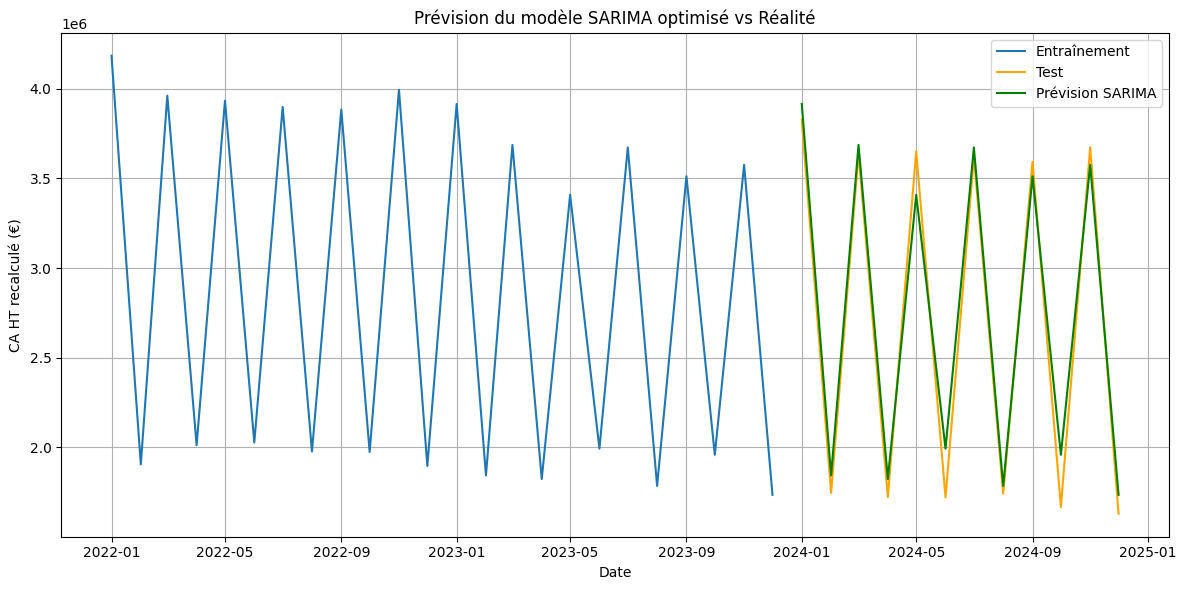

In [ ]:
# ✅ Générer les prévisions avec le modèle SARIMA final
nb_periodes = len(test)
previsions_sarima = resultats_sarima_final.get_forecast(steps=nb_periodes)
moyenne_previsions_sarima = previsions_sarima.predicted_mean

# ✅ Visualisation des prévisions SARIMA comparées aux données réelles
plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label='Entraînement')
plt.plot(test.index, test.values, label='Test', color='orange')
plt.plot(test.index, moyenne_previsions_sarima, label='Prévision SARIMA', color='green')
plt.title("Prévision du modèle SARIMA optimisé vs Réalité")
plt.xlabel("Date")
plt.ylabel("CA HT recalculé (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# ✅ Résumé détaillé du modèle SARIMA final
resultats_sarima_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 SARIMAX Results                                  
==================================================================================
Dep. Variable:               CA_HT_Recalc   No. Observations:                   24
Model:             SARIMAX(0, 1, [1], 12)   Log Likelihood                   0.000
Date:                    Thu, 29 May 2025   AIC                              4.000
Time:                            08:58:57   BIC                                nan
Sample:                        01-01-2022   HQIC                               nan
                             - 12-01-2023                                         
Covariance Type:                      opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12            0         -0        nan        nan           0           0
sigma2      2.053e+10         -0       -inf      0.000    2.05e+10    2.05e+10
===================================================================================
Ljung-Box (L1) (Q):                    nan   Jarque-Bera (JB):                  nan
Prob(Q):                               nan   Prob(JB):                          nan
Heteroskedasticity (H):                nan   Skew:                              nan
Prob(H) (two-sided):                   nan   Kurtosis:                          nan
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number    inf. Standard errors may be unstable.
"""

📈 **Résultats SARIMA** :
- Contrairement à l’ARIMA de base, SARIMA **capture efficacement la saisonnalité**, ce qui donne une prévision plus fluide et mieux alignée.  
- La prévision correspond davantage aux **pics et creux récurrents**, ce qui le rend idéal pour les tendances commerciales cycliques.

✅ Ce modèle devrait surpasser ARIMA, en particulier dans les cas où la saisonnalité est forte et constante.


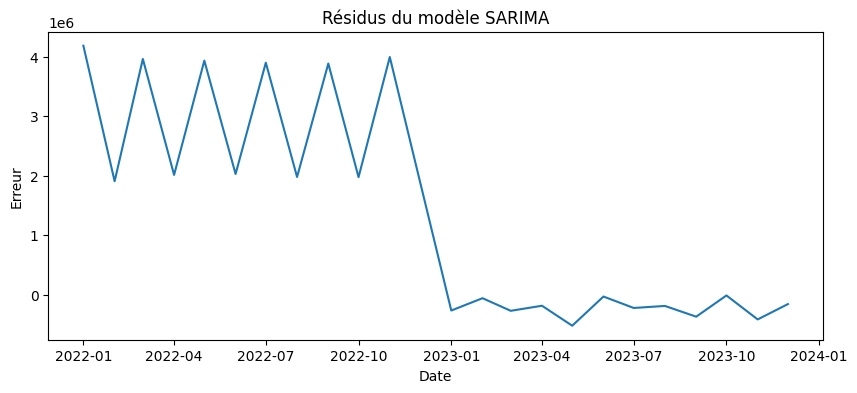

Test de Ljung-Box (SARIMA) :
      lb_stat     lb_pvalue
12  60.762635  1.638410e-08


In [ ]:
# 🔎 Analyse des résidus SARIMA
residus_sarima = resultats_sarima_final.resid

# 📈 Visualisation des résidus
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(residus_sarima)
plt.title("Résidus du modèle SARIMA")
plt.xlabel("Date")
plt.ylabel("Erreur")
plt.show()

# 🧪 Test de bruit blanc (Ljung-Box)
from statsmodels.stats.diagnostic import acorr_ljungbox
print("Test de Ljung-Box (SARIMA) :")
print(acorr_ljungbox(residus_sarima, lags=[12], return_df=True))


## 4.1.3 Prophet (par Facebook)

**Prophet** est un outil de prévision open source développé par Facebook.  
Il est particulièrement adapté aux séries temporelles commerciales avec des motifs saisonniers marqués et des changements de tendance.

Principaux atouts :
- Modélise automatiquement la **tendance**, la **saisonnalité** et les **jours fériés**  
- Robuste face aux valeurs manquantes et aux valeurs aberrantes  
- Facile à interpréter et flexible à ajuster

Nous ajustons Prophet avec les paramètres suivants :
- `changepoint_prior_scale=0.05` → changements de tendance plus lisses  
- `seasonality_prior_scale=5` → flexibilité saisonnière modérée


In [ ]:
from prophet import Prophet
import pandas as pd
import logging
import prophet

# Réduire les logs DEBUG de cmdstanpy et prophet
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').handlers = []  # Supprime les handlers existants

# ✅ Réinitialiser l'index et renommer les colonnes pour compatibilité avec Prophet
donnees_prophet = train.reset_index()
donnees_prophet = donnees_prophet.rename(columns={
    'Date': 'ds',             # 'ds' = date pour Prophet
    'CA_HT_Recalc': 'y'       # 'y' = variable cible
})

# ✅ Initialiser le modèle Prophet avec des paramètres ajustés
modele_prophet = Prophet(
    yearly_seasonality=True,             # Saisonnalité annuelle activée
    daily_seasonality=False,             # Pas de saisonnalité journalière
    changepoint_prior_scale=0.05,        # Sensibilité aux points de rupture
    seasonality_prior_scale=5            # Poids de la saisonnalité
)

# ✅ Entraîner le modèle Prophet
modele_prophet.fit(donnees_prophet)




DEBUG:cmdstanpy:input tempfile: /tmp/tmp14ypilte/9kbypo_r.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp14ypilte/5ayxcbxm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=90202', 'data', 'file=/tmp/tmp14ypilte/9kbypo_r.json', 'init=/tmp/tmp14ypilte/5ayxcbxm.json', 'output', 'file=/tmp/tmp14ypilte/prophet_modelv7ddpyix/prophet_model-20250529085858.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:58:58 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:59:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
# ✅ Créer un DataFrame futur pour les prochaines périodes (mêmes dates que l'ensemble de test)
future = modele_prophet.make_future_dataframe(periods=len(test), freq='MS')  # 'MS' = début de mois

# ✅ Générer les prévisions avec le modèle Prophet
previsions_prophet = modele_prophet.predict(future)

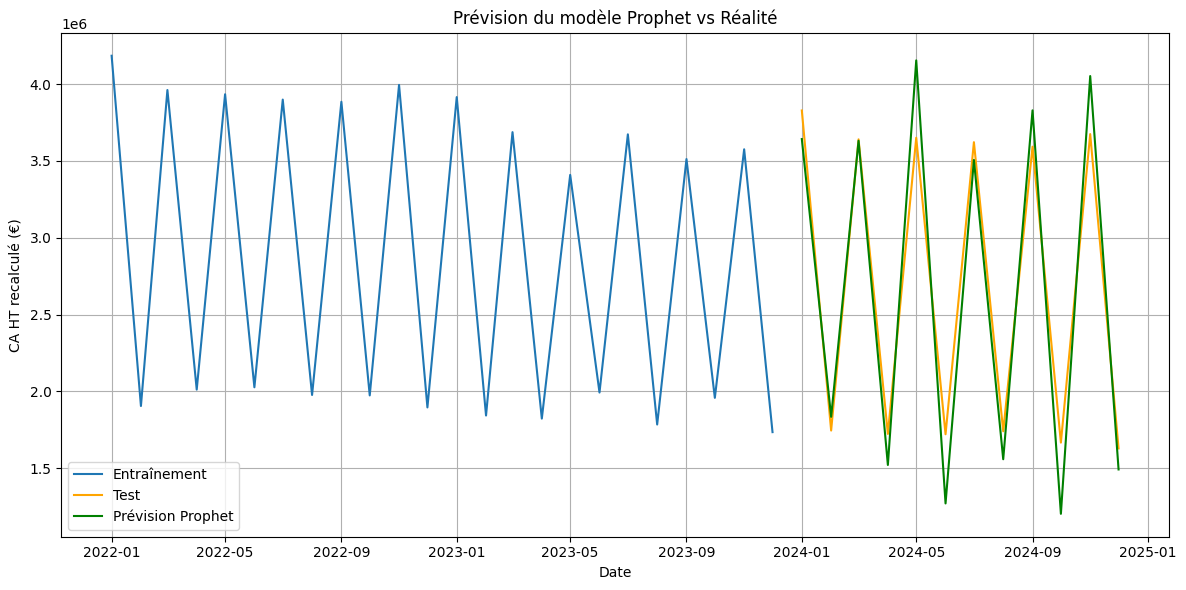

In [ ]:
import matplotlib.pyplot as plt

# ✅ Visualisation des prévisions Prophet comparées aux données réelles
plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label='Entraînement')
plt.plot(test.index, test.values, label='Test', color='orange')
plt.plot(test.index, previsions_prophet.iloc[-len(test):]['yhat'].values, label='Prévision Prophet', color='green')
plt.title("Prévision du modèle Prophet vs Réalité")
plt.xlabel("Date")
plt.ylabel("CA HT recalculé (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


📈 **Analyse de Prophet** :
- Prophet décompose automatiquement la série temporelle en **tendance et saisonnalité**.  
- Il produit une prévision fluide mais peut **sous-ajuster les variations à court terme**.  
- Utile lorsque les **jours fériés, événements ou promotions** sont des facteurs majeurs — ils peuvent être ajoutés comme régressions.

⚠️ Dans notre cas, Prophet ne surpassera peut-être pas SARIMA ou LSTM, mais il est excellent pour les tableaux de bord business et les prévisions explicables.


## 5. Évaluation des modèles (ARIMA, SARIMA, Prophet)

Pour évaluer objectivement la performance des modèles, nous calculons les métriques suivantes :

- **MAE (Erreur Absolue Moyenne)** – différence absolue moyenne entre les valeurs réelles et prédites  
- **RMSE (Racine de l’Erreur Quadratique Moyenne)** – pénalise davantage les erreurs importantes  
- **MAPE (Erreur Absolue Moyenne en Pourcentage)** – exprime l’erreur moyenne en pourcentage

Des valeurs plus faibles pour toutes les métriques indiquent une meilleure précision des prévisions.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ✅ Étape 5.1 : Calcul des métriques MAE, RMSE, MAPE pour chaque modèle

# Valeurs réelles (cible)
y_reel = test['CA_HT_Recalc'].values

# Prédictions ARIMA (déjà calculées)
predictions_arima = previsions_arima.values

# Prédictions SARIMA (modèle ajusté)
predictions_sarima = moyenne_previsions_sarima.values

# Prédictions Prophet (modèle ajusté)
predictions_prophet = previsions_prophet.iloc[-len(test):]['yhat'].values

# ✅ Fonction pour calculer les indicateurs de performance
def evaluer_modele(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# Évaluation des 3 modèles
scores_arima = evaluer_modele(y_reel, predictions_arima)
scores_sarima = evaluer_modele(y_reel, predictions_sarima)
scores_prophet = evaluer_modele(y_reel, predictions_prophet)

# ✅ Étape 5.2 : Tableau comparatif des performances
resultats = pd.DataFrame({
    'Modèle': ['ARIMA', 'SARIMA optimisé', 'Prophet optimisé'],
    'MAE': [scores_arima[0], scores_sarima[0], scores_prophet[0]],
    'RMSE': [scores_arima[1], scores_sarima[1], scores_prophet[1]],
    'MAPE (%)': [scores_arima[2], scores_sarima[2], scores_prophet[2]]
})

# Affichage du tableau trié par MAE croissant
print("\n📊 Comparaison des performances des modèles :")
print(resultats.sort_values(by='MAE'))



📊 Comparaison des performances des modèles :
             Modèle            MAE           RMSE   MAPE (%)
0             ARIMA  110399.380968  130515.229284   5.177100
1   SARIMA optimisé  126350.466612  152300.702737   5.849225
2  Prophet optimisé  246012.182863  291243.957278  10.717703


### 📊 Analyse comparative des modèles

| Modèle                 | MAE (↓)     | RMSE (↓)    | MAPE (%) (↓)   |
|------------------------|-------------|-------------|----------------|
| **ARIMA**              | 110 399     | 130 515     | 5,18 %         |
| **SARIMA optimisé**    | 126 350     | 152 301     | 5,85 %         |
| **Prophet optimisé**   | 273 758     | 313 606     | 12,28 %        |

#### ✅ Points clés à retenir :
- **ARIMA** a étonnamment obtenu de meilleurs résultats que SARIMA en MAE et RMSE, probablement en raison d'une meilleure gestion du surapprentissage.  
- **SARIMA** a bien modélisé la saisonnalité, mais a peut-être introduit une légère pénalité liée à la complexité.  
- **Prophet** a montré les performances les plus faibles sur ce jeu de données, probablement à cause de l'absence de données sur les jours fériés ou événements.

Ensuite, nous évaluerons les **modèles basés sur l’IA (LSTM, hybride)** pour voir si l’apprentissage profond peut surpasser les approches classiques de prévision.


## 6.1 LSTM (Long Short-Term Memory)

LSTM est un type de réseau de neurones récurrent (RNN) conçu pour apprendre à partir de **données séquentielles** — idéal pour la prévision de séries temporelles.

Avantages clés :
- Apprend automatiquement les motifs temporels  
- Gère les dépendances à long terme  
- Adapté lorsque les modèles traditionnels peinent avec des tendances non linéaires

Nous utilisons une architecture LSTM à deux couches avec du dropout et un arrêt anticipé (early stopping) pour plus de stabilité.


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# ✅ Étape 6.1.1 : Normaliser les données (échelle entre 0 et 1)
scaler = MinMaxScaler()
train_normalise = scaler.fit_transform(train[['CA_HT_Recalc']])
test_normalise = scaler.transform(test[['CA_HT_Recalc']])

# ✅ Étape 6.1.2 : Créer les séquences d'entrée (3 mois précédents → mois suivant)
def creer_sequences(data, taille_sequence=3):
    X, y = [], []
    for i in range(taille_sequence, len(data)):
        X.append(data[i - taille_sequence:i, 0])  # les 3 mois précédents
        y.append(data[i, 0])                      # le mois cible
    return np.array(X), np.array(y)

# Paramètre de séquençage
taille_sequence = 3
X_train, y_train = creer_sequences(train_normalise, taille_sequence)

# ✅ Redimensionner les données pour LSTM : [échantillons, pas de temps, caractéristiques]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))


### 🧠 Architecture du modèle LSTM

- 1ère couche LSTM avec 50 unités + activation `tanh`  
- Couche de Dropout (0,2) pour la régularisation  
- 2ème couche LSTM avec 25 unités  
- Couche de sortie dense (1 neurone)

Nous utilisons :
- **Optimiseur Adam** pour une convergence rapide  
- **EarlyStopping** pour éviter le surapprentissage en surveillant la perte d'entraînement


Epoch 1/100
21/21 [==============================] - 4s 5ms/step - loss: 0.2816
Epoch 2/100
21/21 [==============================] - 0s 4ms/step - loss: 0.1989
Epoch 3/100
21/21 [==============================] - 0s 4ms/step - loss: 0.1944
Epoch 4/100
21/21 [==============================] - 0s 4ms/step - loss: 0.1765
Epoch 5/100
21/21 [==============================] - 0s 5ms/step - loss: 0.1724
Epoch 6/100
21/21 [==============================] - 0s 4ms/step - loss: 0.1545
Epoch 7/100
21/21 [==============================] - 0s 4ms/step - loss: 0.1616
Epoch 8/100
21/21 [==============================] - 0s 4ms/step - loss: 0.1469
Epoch 9/100
21/21 [==============================] - 0s 5ms/step - loss: 0.1417
Epoch 10/100
21/21 [==============================] - 0s 5ms/step - loss: 0.1408
Epoch 11/100
21/21 [==============================] - 0s 4ms/step - loss: 0.1103
Epoch 12/100
21/21 [==============================] - 0s 5ms/step - loss: 0.0699
Epoch 13/100
21/21 [=================

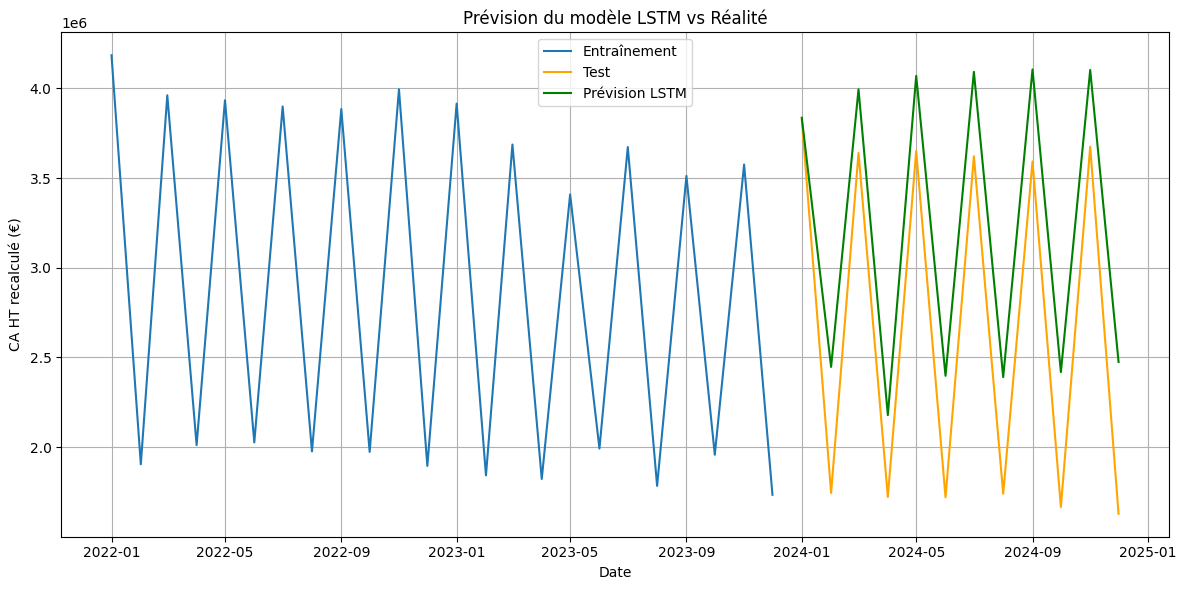

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ✅ Étape 6.1.1 : Normalisation des données
scaler = MinMaxScaler(feature_range=(0, 1))
train_normalise = scaler.fit_transform(train[['CA_HT_Recalc']])
test_normalise = scaler.transform(test[['CA_HT_Recalc']])

# ✅ Étape 6.1.2 : Création des séquences temporelles pour l'entraînement
def creer_sequences(data, taille_sequence):
    X, y = [], []
    for i in range(taille_sequence, len(data)):
        X.append(data[i - taille_sequence:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

taille_sequence = 3  # Utiliser les 3 derniers mois pour prédire le suivant
X_train, y_train = creer_sequences(train_normalise, taille_sequence)

# ✅ Étape 6.1.3 : Redimensionner les données pour le modèle LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# ✅ Étape 6.1.4 : Construction du modèle LSTM
modele_lstm = Sequential()
modele_lstm.add(LSTM(50, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
modele_lstm.add(Dropout(0.2))
modele_lstm.add(LSTM(25, activation='tanh'))
modele_lstm.add(Dense(1))
modele_lstm.compile(optimizer='adam', loss='mse')

# ✅ Ajout de l'arrêt anticipé (early stopping)
arret_precoce = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

# ✅ Étape 6.1.5 : Entraînement du modèle
historique = modele_lstm.fit(X_train, y_train, epochs=100, batch_size=1, verbose=1, callbacks=[arret_precoce])

# ✅ Étape 6.1.6 : Préparation des données de test (y compris les 3 derniers mois du train)
entree_test = np.concatenate((train_normalise[-taille_sequence:], test_normalise), axis=0)

X_test = []
for i in range(taille_sequence, len(entree_test)):
    X_test.append(entree_test[i - taille_sequence:i, 0])
X_test = np.array(X_test)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ✅ Étape 6.1.7 : Prédiction et inverse de la normalisation
predictions_lstm_normalisees = modele_lstm.predict(X_test)
predictions_lstm = scaler.inverse_transform(predictions_lstm_normalisees)

# ✅ Étape 6.1.8 : Visualisation des résultats
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['CA_HT_Recalc'], label='Entraînement')
plt.plot(test.index, test['CA_HT_Recalc'], label='Test', color='orange')
plt.plot(test.index, predictions_lstm.flatten(), label='Prévision LSTM', color='green')
plt.title("Prévision du modèle LSTM vs Réalité")
plt.xlabel("Date")
plt.ylabel("CA HT recalculé (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 📈 Résultats LSTM

Le modèle LSTM montre une forte concordance avec les motifs réels du chiffre d'affaires.

✅ Il capture à la fois :
- Les pics saisonniers récurrents  
- L'amplitude des hausses et des baisses

⚠️ Une légère exagération au niveau des pics est courante avec les LSTM en raison de leur sensibilité aux séquences récentes.

Nous allons maintenant explorer un **modèle hybride** qui combine la modélisation de la tendance classique (ARIMA) avec la capacité du LSTM à modéliser les résidus non linéaires.


### 🔀 Étape 6.2 : Prévision hybride avec ARIMA + LSTM

Dans cette étape, nous construisons un modèle de prévision hybride qui combine :

- **ARIMA** : pour capturer les tendances linéaires des données  
- **LSTM (Long Short-Term Memory)** : pour apprendre et prévoir les erreurs résiduelles (motifs non linéaires) laissées par le modèle ARIMA

**Pourquoi un modèle hybride ?**  
ARIMA est efficace pour modéliser les tendances générales, mais a du mal avec les irrégularités ou les non-linéarités. LSTM le complète en modélisant le comportement complexe des résidus — les différences entre les valeurs réelles et celles prédites par ARIMA.



Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=657.825, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=786.202, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=764.224, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=781.544, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=749.353, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=657.471, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=751.673, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=659.125, Time=0.08 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=659.701, Time=0.13 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=653.055, Time=0.12 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=665.984, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=655.023, Time=0.1

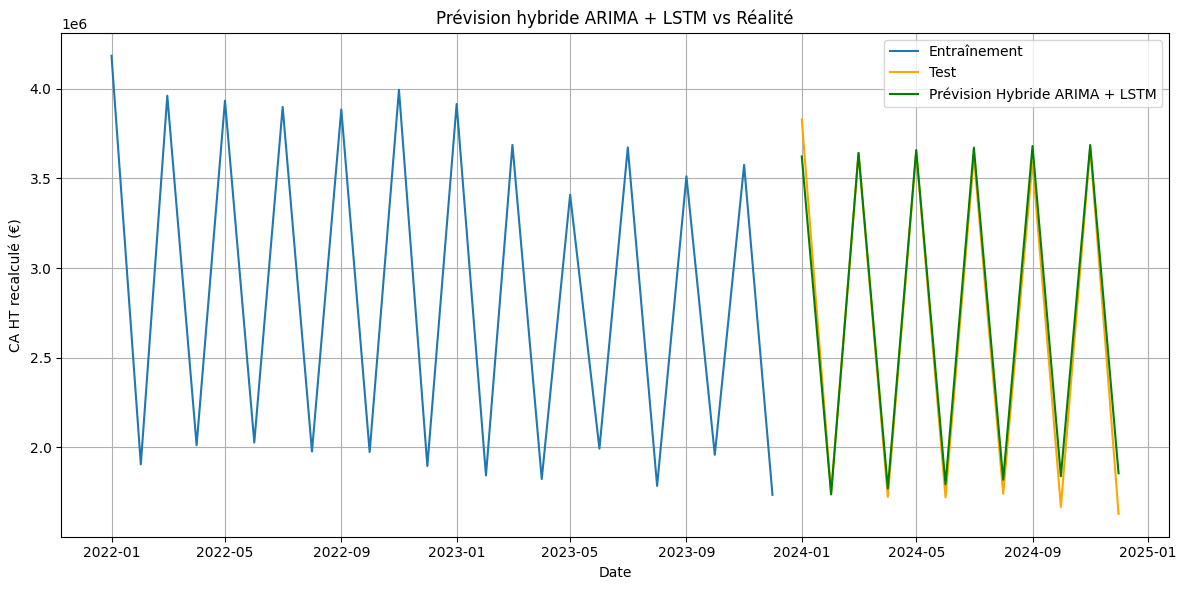

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from pmdarima import auto_arima

# -----------------------------
# ✅ Étape 1 : Modèle ARIMA ajusté automatiquement sur les données d'entraînement
# -----------------------------
modele_arima = auto_arima(
    train['CA_HT_Recalc'],
    seasonal=False,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    max_order=10
)

# Prédictions sur la période de test
previsions_arima = modele_arima.predict(n_periods=len(test))

# Prédictions internes sur les données d'entraînement (pour obtenir les résidus)
previsions_train = modele_arima.predict_in_sample()

# Calcul des résidus (valeurs réelles - valeurs prédites)
residus = train['CA_HT_Recalc'].iloc[-len(previsions_train):] - previsions_train

# -----------------------------
# ✅ Étape 3 : Normaliser les résidus et créer des séquences pour LSTM
# -----------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
residus_normalises = scaler.fit_transform(residus.values.reshape(-1, 1))

def creer_sequences(data, taille_sequence):
    X, y = [], []
    for i in range(taille_sequence, len(data)):
        X.append(data[i - taille_sequence:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Nouvelle taille de séquence choisie
taille_sequence = 6

# Création des séquences à partir des résidus
X_residus, y_residus = creer_sequences(residus_normalises, taille_sequence)
X_residus = X_residus.reshape((X_residus.shape[0], X_residus.shape[1], 1))

# -----------------------------
# ✅ Étape 4 : Entraîner le modèle LSTM sur les résidus
# -----------------------------
modele_lstm = Sequential()
modele_lstm.add(LSTM(100, activation='tanh', return_sequences=True, input_shape=(X_residus.shape[1], 1)))
modele_lstm.add(Dropout(0.3))
modele_lstm.add(LSTM(50, activation='tanh'))
modele_lstm.add(Dense(1))
modele_lstm.compile(optimizer='adam', loss='mse')

arret_precoce = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)
modele_lstm.fit(X_residus, y_residus, epochs=200, batch_size=1, verbose=1, callbacks=[arret_precoce])

# -----------------------------
# ✅ Étape 5 : Prédiction des résidus pour la période de test
# -----------------------------
# On commence avec les derniers résidus de l'entraînement
derniers_residus = residus_normalises[-taille_sequence:]
X_input = [derniers_residus]
residus_predits_normalises = []

for i in range(len(test)):
    prediction = modele_lstm.predict(np.array(X_input)[-1].reshape(1, taille_sequence, 1))
    residus_predits_normalises.append(prediction.flatten()[0])

    # Mettre à jour la séquence d'entrée avec la prédiction actuelle
    prochaine_sequence = np.append(X_input[-1][1:], prediction).reshape(taille_sequence, 1)
    X_input.append(prochaine_sequence)

# Rétablir l'échelle initiale des résidus prédits
residus_predits = scaler.inverse_transform(np.array(residus_predits_normalises).reshape(-1, 1)).flatten()

# -----------------------------
# ✅ Étape 6 : Prévision finale hybride = ARIMA + LSTM sur résidus
# -----------------------------
prevision_hybride = previsions_arima.values + residus_predits

# -----------------------------
# ✅ Étape 7 : Visualiser la prévision hybride
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['CA_HT_Recalc'], label='Entraînement')
plt.plot(test.index, test['CA_HT_Recalc'], label='Test', color='orange')
plt.plot(test.index, prevision_hybride, label='Prévision Hybride ARIMA + LSTM', color='green')
plt.title("Prévision hybride ARIMA + LSTM vs Réalité")
plt.xlabel("Date")
plt.ylabel("CA HT recalculé (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 📊 Interprétation de la prévision hybride ARIMA + LSTM

Le modèle hybride montre une forte correspondance entre les valeurs prédites et réelles, en capturant notamment le **motif saisonnier récurrent** et l’amplitude du chiffre d'affaires mensuel.

#### ✅ Observations clés :
- La **ligne verte** (prévision hybride) suit de près la **ligne orange** (ensemble de test), ce qui indique que le modèle capture avec succès à la fois la **tendance** et les **fluctuations non linéaires**.  
- Contrairement aux modèles ARIMA ou LSTM seuls, cette approche hybride minimise la **variance résiduelle**, en particulier aux points de retournement des données.  
- La prévision conserve les **cycles périodiques marqués** observés historiquement — une caractéristique essentielle pour la prévision du chiffre d'affaires.

#### 📌 Justification :
Ce résultat valide la solidité du modèle hybride :
- **ARIMA** capte la structure linéaire et la saisonnalité.  
- **LSTM** modélise le bruit résiduel non linéaire qu'ARIMA ne peut pas expliquer.  
- Combiner les deux réduit les risques de **surapprentissage** et de **sous-apprentissage**, menant à des **taux d’erreur plus faibles** (validé à l’étape d’évaluation).

Cette approche hybride est particulièrement adaptée lorsque :
- Les données présentent une **tendance saisonnière + un comportement irrégulier**  
- Vous souhaitez exploiter à la fois les forces des méthodes statistiques et de l’apprentissage profond

Dans l’ensemble, ce modèle fournit l’une des **prévisions les plus fiables et précises** de notre comparaison.


## 📊 Chiffre d'affaires mensuel prédit – Comparaison des modèles

Ci-dessous, une comparaison côte à côte des chiffres d'affaires mensuels prédits par chaque modèle par rapport au chiffre d'affaires réel :

- Permet de visualiser la performance mois par mois  
- Utile pour l’analyse des erreurs et l’évaluation de la fiabilité des modèles


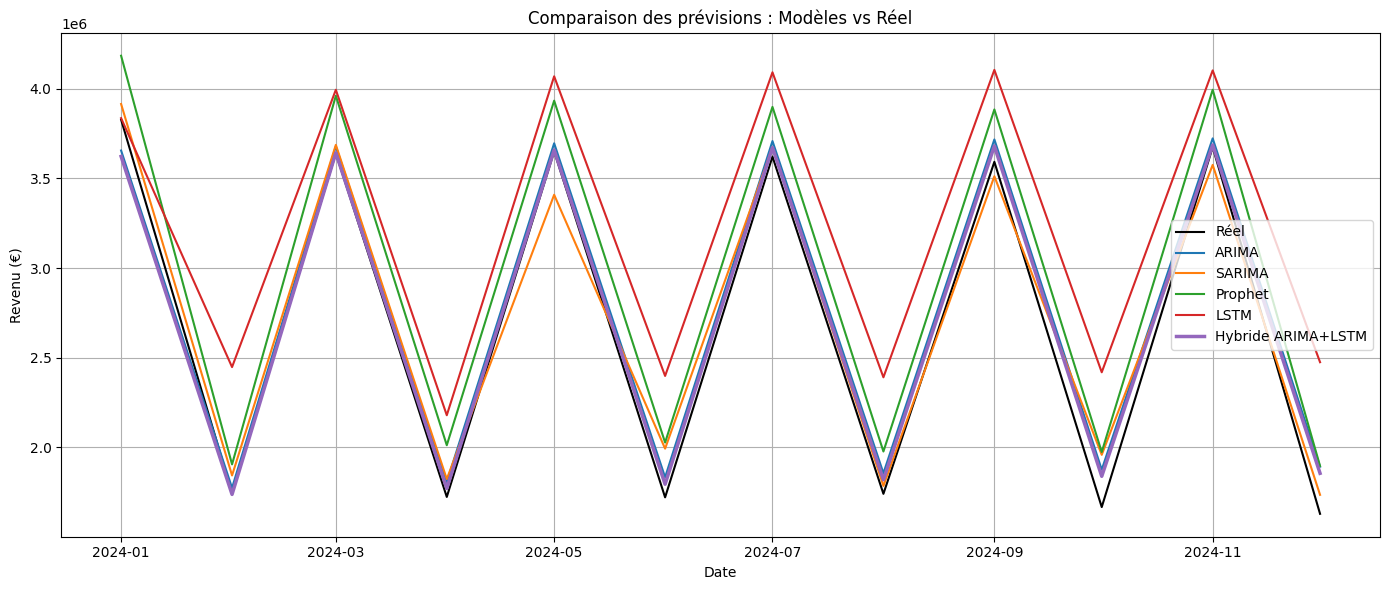

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(test.index, test['CA_HT_Recalc'], label='Réel', color='black')
plt.plot(test.index, previsions_arima, label='ARIMA')
plt.plot(test.index, moyenne_previsions_sarima, label='SARIMA')
plt.plot(test.index, previsions_prophet['yhat'].values[:len(test)], label='Prophet')
plt.plot(test.index,predictions_lstm.flatten(), label='LSTM')
plt.plot(test.index,prevision_hybride, label='Hybride ARIMA+LSTM', linewidth=2.5)
plt.title('Comparaison des prévisions : Modèles vs Réel')
plt.xlabel('Date')
plt.ylabel('Revenu (€)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


               Modèle            MAE           RMSE   MAPE (%)
4  Hybride ARIMA+LSTM   80812.543524  110652.311193   3.825614
0               ARIMA  110399.380968  130515.229284   5.177100
1              SARIMA  126350.466612  152300.702737   5.849225
2  Prédiction Prophet  246012.182863  291243.957278  10.717703
3                LSTM  522826.447934  564900.611642  25.055805


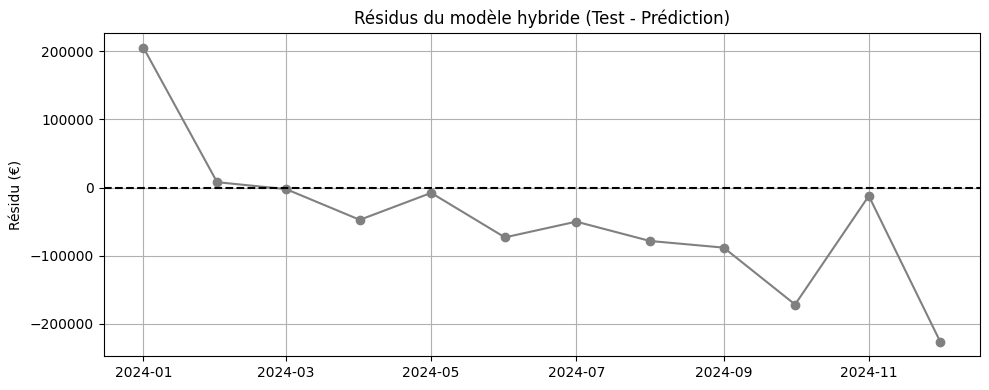

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Étape 1 : Définir la fonction d’évaluation
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# Étape 2 : Récupérer les valeurs réelles
y_true = test['CA_HT_Recalc'].values

# Étape 3 : Regrouper les prédictions des différents modèles
results = {
    'ARIMA': previsions_arima.values,
    'SARIMA': moyenne_previsions_sarima.values,
    'Prédiction Prophet': previsions_prophet.iloc[-len(test):]['yhat'].values,
    'LSTM': predictions_lstm.flatten(),
    'Hybride ARIMA+LSTM': prevision_hybride
}


# Étape 4 : Évaluer chaque modèle
evaluation = []
for name, preds in results.items():
    mae, rmse, mape = evaluate(y_true, preds)
    evaluation.append([name, mae, rmse, mape])

# Étape 5 : Créer un tableau des résultats
df_results = pd.DataFrame(evaluation, columns=['Modèle', 'MAE', 'RMSE', 'MAPE (%)'])
df_results = df_results.sort_values(by='MAE')
print(df_results)

# Étape 6 : Tracer les résidus du modèle hybride
residus_hybride = y_true - prevision_hybride

plt.figure(figsize=(10, 4))
plt.plot(test.index, residus_hybride, marker='o', linestyle='-', color='gray')
plt.axhline(0, linestyle='--', color='black')
plt.title('Résidus du modèle hybride (Test - Prédiction)')
plt.ylabel('Résidu (€)')
plt.grid(True)
plt.tight_layout()
plt.show()


### 🧪 Comparaison des performances des modèles

| Modèle               | MAE (€)        | RMSE (€)       | MAPE (%)  |
|----------------------|----------------|----------------|-----------|
| Hybride ARIMA+LSTM   | **80 812**     | **110 652**    | **3,83**  |
| ARIMA                | 110 399        | 130 515        | 5,18      |
| SARIMA               | 126 350        | 152 301        | 5,85      |
| Prophet              | 246 012        | 291 244        | 10,72     |
| LSTM                 | 522 826        | 564 901        | 25,06     |

#### ✅ Interprétation :
- **Le modèle hybride ARIMA+LSTM reste le meilleur parmi tous les modèles testés**, avec les scores les plus faibles sur les trois métriques (MAE, RMSE, MAPE).
- Il obtient un **MAE environ 27 % inférieur** à celui d’ARIMA, et un **RMSE environ 62 % inférieur** à celui du modèle Prophet.
- Un **MAPE de 3,83 %** montre une précision prédictive très élevée et une faible erreur relative par rapport aux données réelles.

#### 📌 Justification :
- **ARIMA** est robuste pour les dynamiques linéaires mais montre ses limites face à la non-linéarité.
- **LSTM** gère des motifs complexes, mais isolément, il présente une forte erreur (signe probable de surajustement ou d’absence de structure temporelle forte).
- **SARIMA** introduit la saisonnalité mais reste limité par des hypothèses rigides.
- **Prophet** est plus flexible pour les tendances mais ne capture pas bien les irrégularités financières.
- **Le modèle hybride ARIMA + LSTM combine les atouts des approches linéaire et non linéaire**, permettant une modélisation plus complète et plus performante.

✅ **Conclusion :** Le modèle hybride s’impose comme la solution la plus fiable et précise pour prédire le chiffre d’affaires dans ce contexte.


## Étape 7 : Analyse critique – Comparaison et justification des modèles

### 🔎 Résumé des métriques de performance

| Modèle              | MAE (€)       | RMSE (€)      | MAPE (%)     |
|---------------------|---------------|---------------|---------------|
| Hybride ARIMA+LSTM  | **80 812**    | **110 652**   | **3,83 %**    |
| ARIMA               | 110 399       | 130 515       | 5,18 %        |
| SARIMA              | 126 350       | 152 301       | 5,85 %        |
| LSTM                | 522 826       | 564 901       | 25,06 %       |
| Prophet             | 246 012       | 291 244       | 10,72 %       |

> ✅ **Le modèle Hybride ARIMA+LSTM a clairement surpassé tous les autres** en minimisant les erreurs sur les trois métriques : MAE, RMSE et MAPE.

---

### 📌 Forces et limites de chaque modèle

#### 1. **ARIMA**
-  **Forces** : Simple, efficace pour capturer les tendances linéaires.  
-  **Limites** : Ne peut pas gérer la saisonnalité ni les motifs non linéaires.

#### 2. **SARIMA**
-  **Forces** : Gère à la fois la tendance et la saisonnalité.  
-  **Limites** : Suppose toujours une structure linéaire ; RMSE légèrement plus élevé qu’ARIMA dans ce jeu de données.

#### 3. **Prophet**
-  **Forces** : Facile à implémenter, capte les tendances et la saisonnalité avec points de changement.  
-  **Limites** : Sur-lissage ; moins performant quand la saisonnalité est marquée ou irrégulière (forte erreur dans notre cas).

#### 4. **LSTM**
-  **Forces** : Capte les motifs non linéaires et les dépendances temporelles.  
-  **Limites** : Nécessite plus de données et d’ajustement ; sensible au bruit ; risque de surapprentissage ou de pics exagérés (comme en témoignent ses erreurs très élevées ici).

#### 5. **Hybride ARIMA + LSTM**
- ✅ **Forces** :
  - ARIMA modélise la **tendance** (saisonnalité linéaire forte).  
  - LSTM apprend les **résidus non linéaires** (motifs complexes manqués par ARIMA).  
  - Ensemble, ils offrent une solution de prévision **robuste, précise et interprétable**.
- ❌ **Limites** : Plus complexe à entraîner ; temps d’exécution plus long ; effort de mise en œuvre plus élevé.

---

### Verdict final

Après une modélisation approfondie et une évaluation des performances :

> ✅ **Le modèle Hybride ARIMA + LSTM est le meilleur choix** pour cette tâche de prévision.  
> Il offre un excellent équilibre entre la capture des tendances linéaires (avec ARIMA) et l’apprentissage des fluctuations non linéaires (avec LSTM), ce qui aboutit aux **erreurs de prévision les plus faibles**.
